# Phase 2: Clinical Text Classification with BERT
**Dataset:** Medical Transcriptions (MTSamples)  
**Task:** Classify medical transcription text into medical specialties  
**Goal:** Beat Phase 1 baseline (Logistic Regression: 27.63%)

### Models:
1. BERT-base
2. BioBERT (biomedical domain)
3. ClinicalBERT (clinical domain)

**Requires GPU** - Make sure Kaggle GPU is enabled.

## 1. Install & Import Libraries

In [1]:
!pip install transformers datasets accelerate -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch version:", torch.__version__)

Device: cuda
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


## 2. Load & Preprocess Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mstarefin/medicaltranscriptions-1/mtsamples.csv")

# Drop missing transcriptions
df = df.dropna(subset=["transcription"])

# Keep specialties with at least 50 samples
specialty_counts = df["medical_specialty"].value_counts()
MIN_SAMPLES = 50
valid_specialties = specialty_counts[specialty_counts >= MIN_SAMPLES].index.tolist()
df_filtered = df[df["medical_specialty"].isin(valid_specialties)].copy()

# Clean text (light cleaning - BERT handles raw text well)
def clean_text(text):
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_filtered["clean_text"] = df_filtered["transcription"].apply(clean_text)

# Encode labels
le = LabelEncoder()
df_filtered["label"] = le.fit_transform(df_filtered["medical_specialty"])
num_labels = len(le.classes_)

print("Samples:", len(df_filtered))
print("Classes:", num_labels)
print("Labels:", list(le.classes_))

Samples: 4647
Classes: 22
Labels: [' Cardiovascular / Pulmonary', ' Consult - History and Phy.', ' Discharge Summary', ' ENT - Otolaryngology', ' Emergency Room Reports', ' Gastroenterology', ' General Medicine', ' Hematology - Oncology', ' Nephrology', ' Neurology', ' Neurosurgery', ' Obstetrics / Gynecology', ' Office Notes', ' Ophthalmology', ' Orthopedic', ' Pain Management', ' Pediatrics - Neonatal', ' Psychiatry / Psychology', ' Radiology', ' SOAP / Chart / Progress Notes', ' Surgery', ' Urology']


## 3. Train / Validation / Test Split

In [3]:
# 70% train, 15% val, 15% test
X = df_filtered["clean_text"].values
y = df_filtered["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 3252
Validation: 697
Test: 698


## 4. Create HuggingFace Datasets

In [4]:
def create_hf_dataset(texts, labels):
    return Dataset.from_dict({"text": texts.tolist(), "label": labels.tolist()})

train_dataset = create_hf_dataset(X_train, y_train)
val_dataset = create_hf_dataset(X_val, y_val)
test_dataset = create_hf_dataset(X_test, y_test)

print("Train dataset:", train_dataset)
print("Val dataset:", val_dataset)
print("Test dataset:", test_dataset)

Train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 3252
})
Val dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 697
})
Test dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 698
})


## 5. Tokenization Helper
BERT has a max token limit of 512. Medical transcriptions are often longer, so we truncate.

In [5]:
MAX_LENGTH = 512

def tokenize_function(examples, tokenizer):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

# Metrics function for Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

## 6. Model Training Function

In [6]:
def train_and_evaluate(model_name, display_name, train_ds, val_ds, test_ds, num_labels):
    print("=" * 60)
    print("Training:", display_name)
    print("Model:", model_name)
    print("=" * 60)
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )
    
    # Tokenize datasets
    tok_fn = lambda examples: tokenize_function(examples, tokenizer)
    train_tokenized = train_ds.map(tok_fn, batched=True)
    val_tokenized = val_ds.map(tok_fn, batched=True)
    test_tokenized = test_ds.map(tok_fn, batched=True)
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir="./results_" + display_name.replace(" ", "_").lower(),
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        warmup_steps=100,
        weight_decay=0.01,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        report_to="none",
        fp16=True if device == "cuda" else False,
    )
    
    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        compute_metrics=compute_metrics,
    )
    
    # Train
    print()
    print("Starting training...")
    trainer.train()
    
    # Evaluate on test set
    print()
    print("Evaluating on test set...")
    predictions = trainer.predict(test_tokenized)
    preds = np.argmax(predictions.predictions, axis=-1)
    test_acc = accuracy_score(test_ds["label"], preds)
    
    print()
    print("{} Test Accuracy: {:.2f}%".format(display_name, test_acc * 100))
    print()
    print("Classification Report:")
    print(classification_report(
        test_ds["label"], preds,
        target_names=le.classes_,
        zero_division=0
    ))
    
    return {
        "name": display_name,
        "model_path": model_name,
        "accuracy": test_acc,
        "predictions": preds,
        "trainer": trainer
    }

## 7. Train BERT-base

In [7]:
bert_results = train_and_evaluate(
    model_name="bert-base-uncased",
    display_name="BERT-base",
    train_ds=train_dataset,
    val_ds=val_dataset,
    test_ds=test_dataset,
    num_labels=num_labels
)

Training: BERT-base
Model: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating on test set...



BERT-base Test Accuracy: 37.11%

Classification Report:
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.17      0.02      0.03        56
    Consult - History and Phy.       0.27      0.88      0.41        78
             Discharge Summary       0.00      0.00      0.00        16
          ENT - Otolaryngology       0.00      0.00      0.00        14
        Emergency Room Reports       0.00      0.00      0.00        11
              Gastroenterology       0.00      0.00      0.00        34
              General Medicine       0.17      0.13      0.15        39
         Hematology - Oncology       0.00      0.00      0.00        13
                    Nephrology       0.00      0.00      0.00        12
                     Neurology       0.00      0.00      0.00        34
                  Neurosurgery       0.00      0.00      0.00        14
       Obstetrics / Gynecology       0.00      0.00      0.00        24
      

## 8. Train BioBERT
BioBERT is pre-trained on biomedical literature (PubMed abstracts + PMC full-text articles).

In [8]:
biobert_results = train_and_evaluate(
    model_name="dmis-lab/biobert-base-cased-v1.2",
    display_name="BioBERT",
    train_ds=train_dataset,
    val_ds=val_dataset,
    test_ds=test_dataset,
    num_labels=num_labels
)

Training: BioBERT
Model: dmis-lab/biobert-base-cased-v1.2


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating on test set...



BioBERT Test Accuracy: 38.54%

Classification Report:
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.43      0.62      0.51        56
    Consult - History and Phy.       0.30      0.68      0.42        78
             Discharge Summary       0.50      0.06      0.11        16
          ENT - Otolaryngology       0.00      0.00      0.00        14
        Emergency Room Reports       0.00      0.00      0.00        11
              Gastroenterology       0.29      0.18      0.22        34
              General Medicine       0.27      0.15      0.20        39
         Hematology - Oncology       0.00      0.00      0.00        13
                    Nephrology       0.00      0.00      0.00        12
                     Neurology       0.50      0.21      0.29        34
                  Neurosurgery       0.00      0.00      0.00        14
       Obstetrics / Gynecology       0.41      0.58      0.48        24
        

## 9. Train ClinicalBERT
ClinicalBERT is pre-trained on clinical notes from MIMIC-III — closest to our task domain.

In [9]:
clinicalbert_results = train_and_evaluate(
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    display_name="ClinicalBERT",
    train_ds=train_dataset,
    val_ds=val_dataset,
    test_ds=test_dataset,
    num_labels=num_labels
)

Training: ClinicalBERT
Model: emilyalsentzer/Bio_ClinicalBERT


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating on test set...



ClinicalBERT Test Accuracy: 38.11%

Classification Report:
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.43      0.66      0.52        56
    Consult - History and Phy.       0.29      0.69      0.41        78
             Discharge Summary       0.00      0.00      0.00        16
          ENT - Otolaryngology       0.00      0.00      0.00        14
        Emergency Room Reports       0.00      0.00      0.00        11
              Gastroenterology       0.19      0.09      0.12        34
              General Medicine       0.00      0.00      0.00        39
         Hematology - Oncology       0.00      0.00      0.00        13
                    Nephrology       0.00      0.00      0.00        12
                     Neurology       0.31      0.29      0.30        34
                  Neurosurgery       0.00      0.00      0.00        14
       Obstetrics / Gynecology       0.33      0.08      0.13        24
   

## 10. Model Comparison
Comparing all models including Phase 1 baseline.

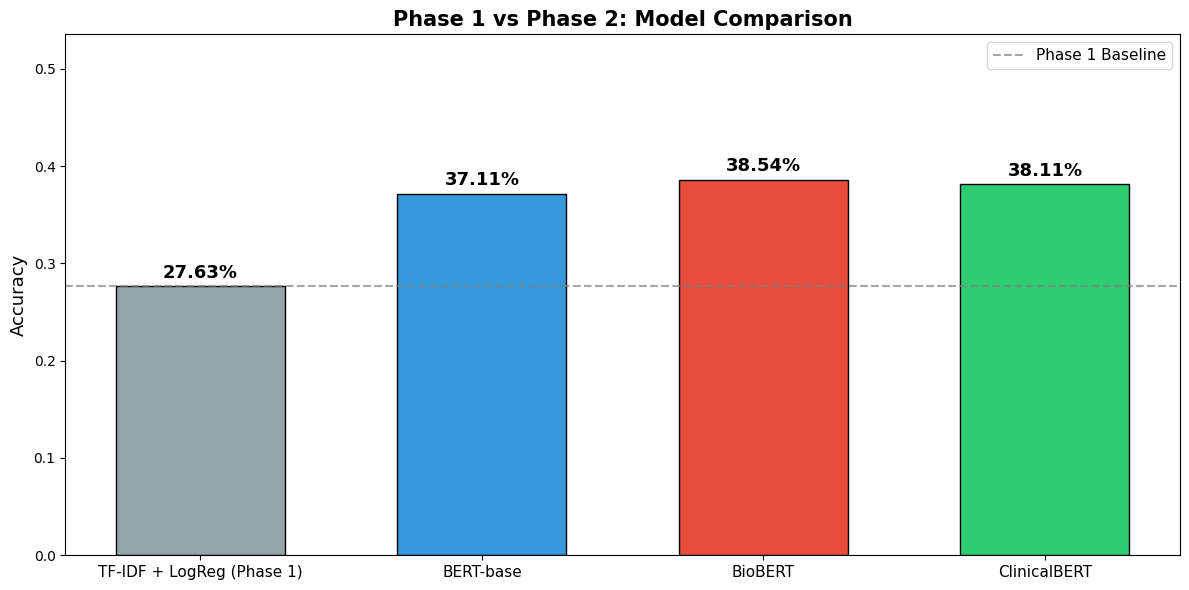


RESULTS SUMMARY
  TF-IDF + LogReg (Phase 1) : 27.63%
  BERT-base : 37.11%
  BioBERT : 38.54%
  ClinicalBERT : 38.11%

Best model: BioBERT
Improvement over Phase 1 baseline: +10.91%


In [10]:
all_results = {
    "TF-IDF + LogReg (Phase 1)": 0.2763,
    "BERT-base": bert_results["accuracy"],
    "BioBERT": biobert_results["accuracy"],
    "ClinicalBERT": clinicalbert_results["accuracy"],
}

names = list(all_results.keys())
accs = list(all_results.values())

plt.figure(figsize=(12, 6))
colors = ["#95a5a6", "#3498db", "#e74c3c", "#2ecc71"]
bars = plt.bar(names, accs, color=colors, edgecolor="black", width=0.6)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             "{:.2f}%".format(acc * 100), ha="center", va="bottom",
             fontweight="bold", fontsize=13)

plt.ylabel("Accuracy", fontsize=13)
plt.title("Phase 1 vs Phase 2: Model Comparison", fontsize=15, fontweight="bold")
plt.ylim(0, max(accs) + 0.15)
plt.xticks(fontsize=11)
plt.axhline(y=0.2763, color="gray", linestyle="--", alpha=0.7, label="Phase 1 Baseline")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print()
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
for name, acc in all_results.items():
    print("  {} : {:.2f}%".format(name, acc * 100))

best_name = max(all_results, key=all_results.get)
improvement = (all_results[best_name] - 0.2763) * 100
print()
print("Best model:", best_name)
print("Improvement over Phase 1 baseline: +{:.2f}%".format(improvement))

## 11. Confusion Matrix - Best BERT Model

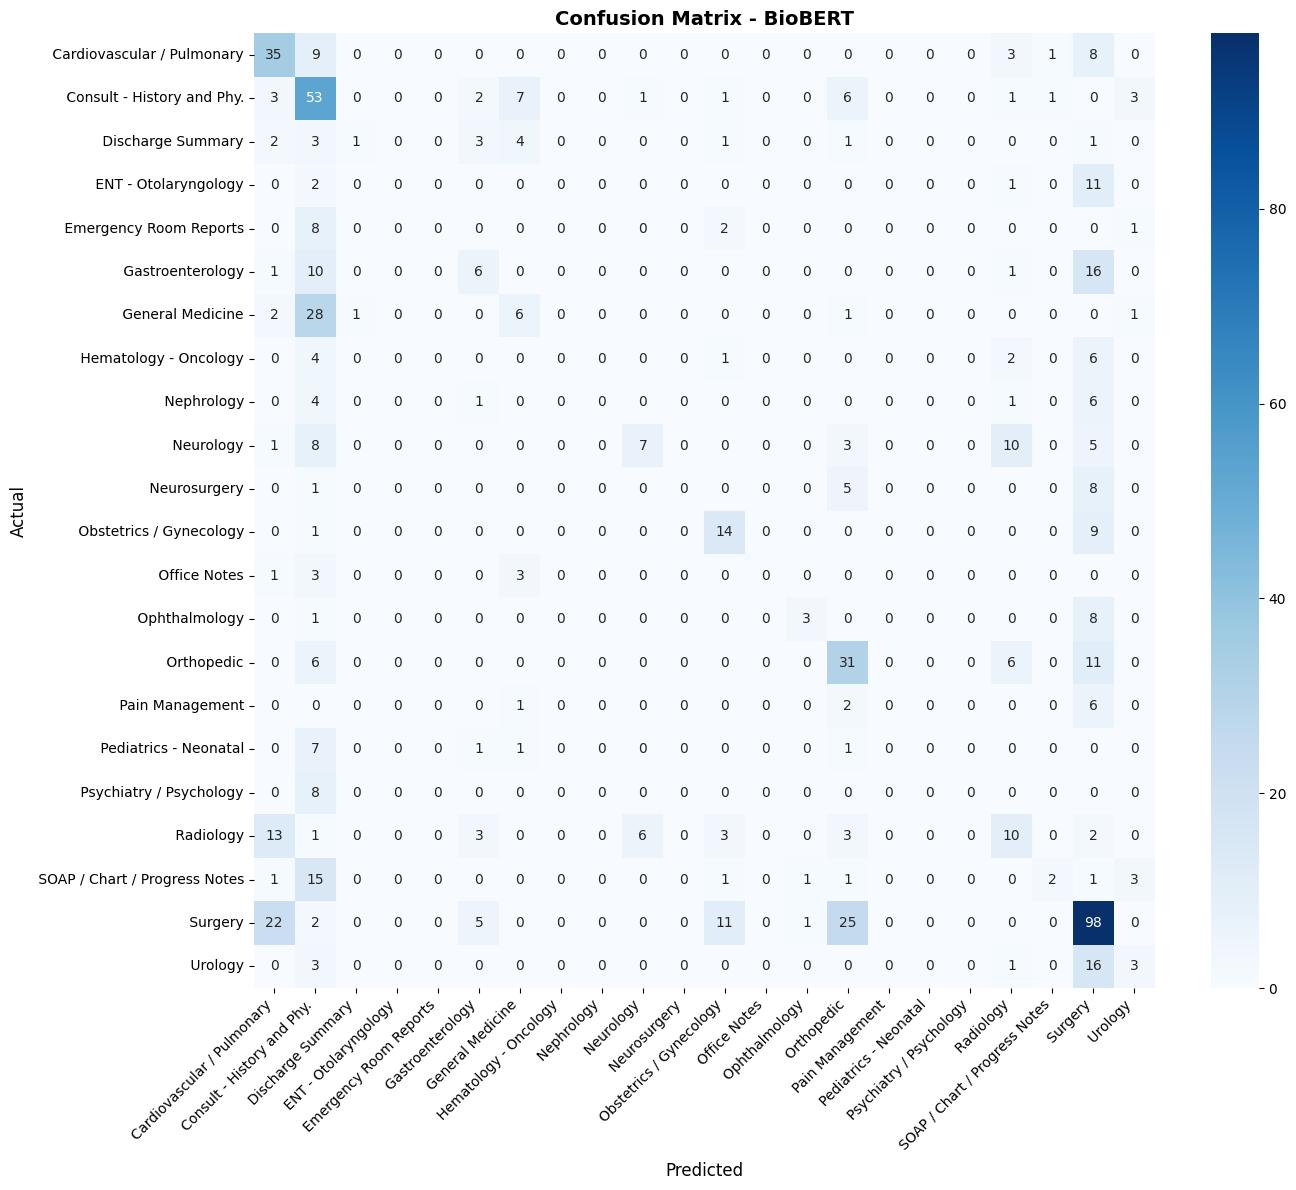

In [11]:
# Pick the best BERT model
bert_models = {"BERT-base": bert_results, "BioBERT": biobert_results, "ClinicalBERT": clinicalbert_results}
best_bert_name = max(bert_models, key=lambda x: bert_models[x]["accuracy"])
best_bert = bert_models[best_bert_name]

cm = confusion_matrix(test_dataset["label"], best_bert["predictions"])

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - " + best_bert_name, fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Per-Class Performance Analysis

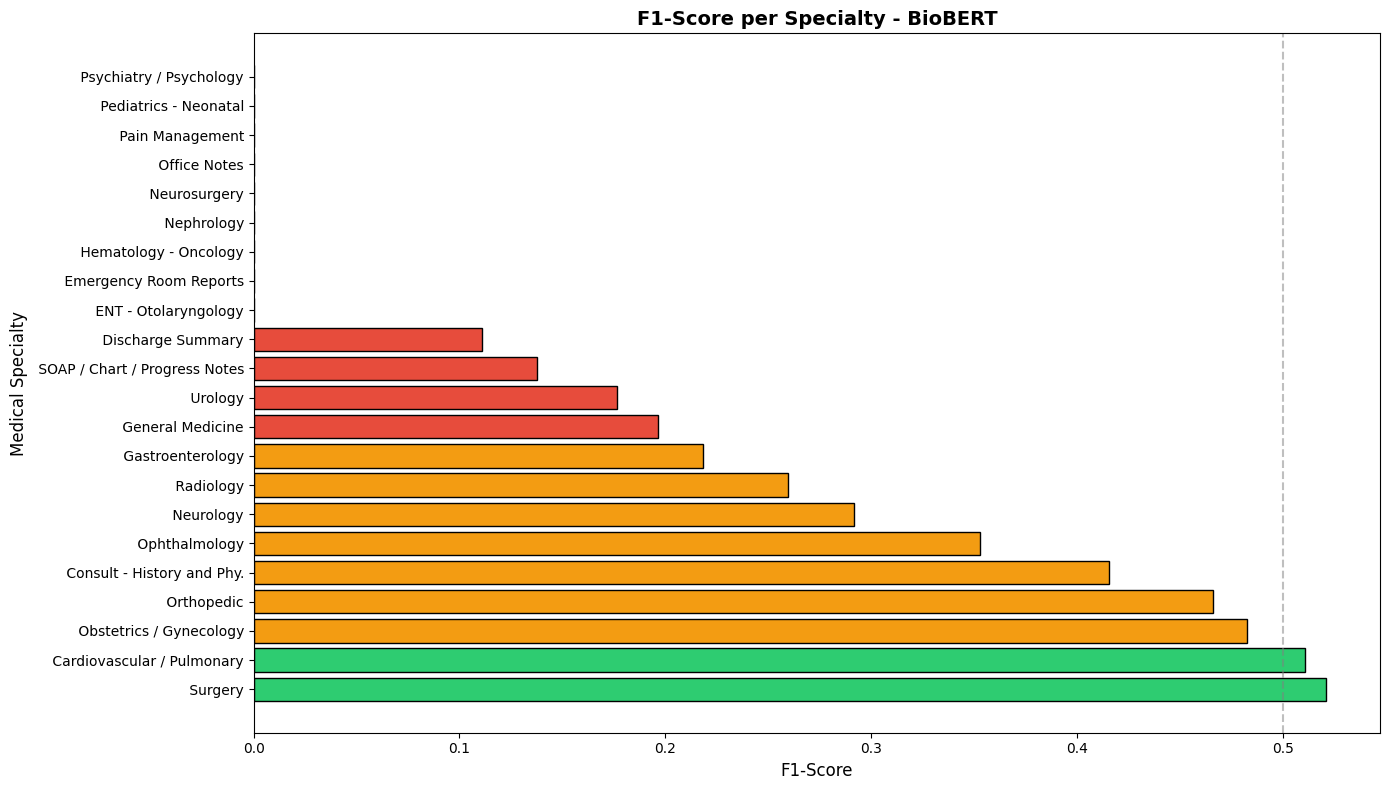

Top 5 specialties (highest F1):
  1.  Surgery : 0.521
  2.  Cardiovascular / Pulmonary : 0.511
  3.  Obstetrics / Gynecology : 0.483
  4.  Orthopedic : 0.466
  5.  Consult - History and Phy. : 0.416

Bottom 5 specialties (lowest F1):
  1.  Neurosurgery : 0.000
  2.  Office Notes : 0.000
  3.  Pain Management : 0.000
  4.  Pediatrics - Neonatal : 0.000
  5.  Psychiatry / Psychology : 0.000


In [12]:
report = classification_report(
    test_dataset["label"], best_bert["predictions"],
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)

# Plot F1 scores per class
class_f1 = {cls: report[cls]["f1-score"] for cls in le.classes_}
sorted_f1 = dict(sorted(class_f1.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(14, 8))
colors_list = ["#2ecc71" if v > 0.5 else "#e74c3c" if v < 0.2 else "#f39c12" for v in sorted_f1.values()]
plt.barh(list(sorted_f1.keys()), list(sorted_f1.values()), color=colors_list, edgecolor="black")
plt.xlabel("F1-Score", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)
plt.title("F1-Score per Specialty - " + best_bert_name, fontsize=14, fontweight="bold")
plt.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 5 specialties (highest F1):")
for i, (cls, f1) in enumerate(list(sorted_f1.items())[:5]):
    print("  {}. {} : {:.3f}".format(i+1, cls, f1))

print()
print("Bottom 5 specialties (lowest F1):")
for i, (cls, f1) in enumerate(list(sorted_f1.items())[-5:]):
    print("  {}. {} : {:.3f}".format(i+1, cls, f1))

## Summary & Next Steps

In [13]:
print("=" * 60)
print("PHASE 2 COMPLETE!")
print("=" * 60)
print()
print("Summary:")
print("- Phase 1 Baseline (TF-IDF + LogReg): 27.63%")
print("- BERT-base: {:.2f}%".format(bert_results["accuracy"] * 100))
print("- BioBERT: {:.2f}%".format(biobert_results["accuracy"] * 100))
print("- ClinicalBERT: {:.2f}%".format(clinicalbert_results["accuracy"] * 100))
print()
print("Next Steps (Phase 3):")
print("- Implement numeric mapping technique")
print("- Convert numbers to categorical levels (very high, high, medium, low, very low)")
print("- Show improvement over base BERT models")
print()
print("Next Steps (Phase 4):")
print("- Explainable AI with LIME and SHAP")
print("- Visualize model decisions")

PHASE 2 COMPLETE!

Summary:
- Phase 1 Baseline (TF-IDF + LogReg): 27.63%
- BERT-base: 37.11%
- BioBERT: 38.54%
- ClinicalBERT: 38.11%

Next Steps (Phase 3):
- Implement numeric mapping technique
- Convert numbers to categorical levels (very high, high, medium, low, very low)
- Show improvement over base BERT models

Next Steps (Phase 4):
- Explainable AI with LIME and SHAP
- Visualize model decisions


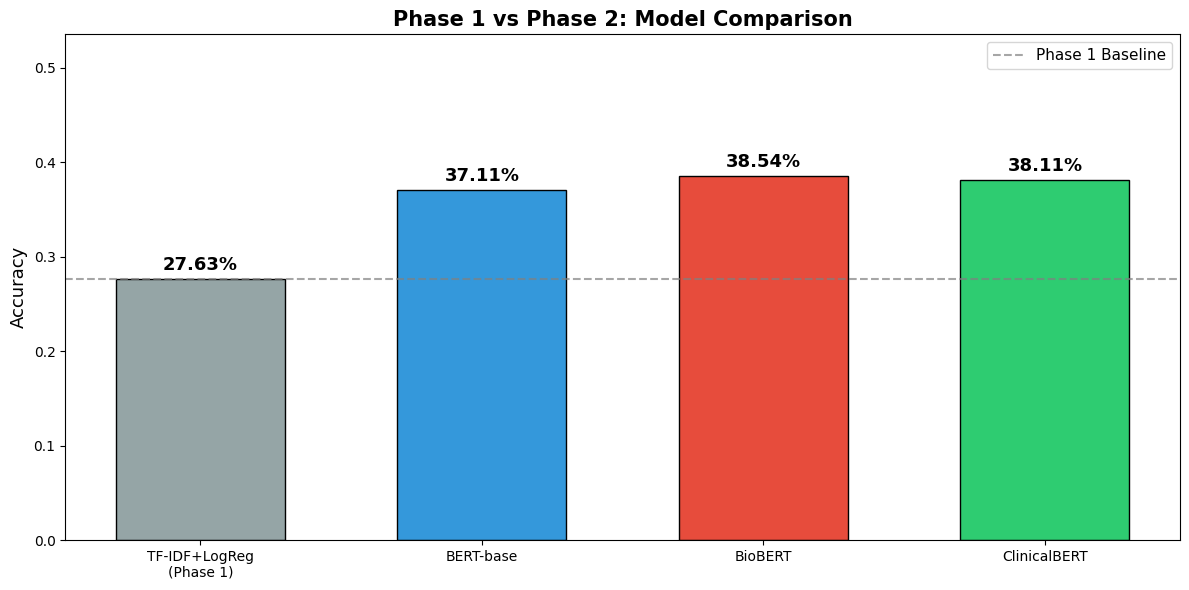

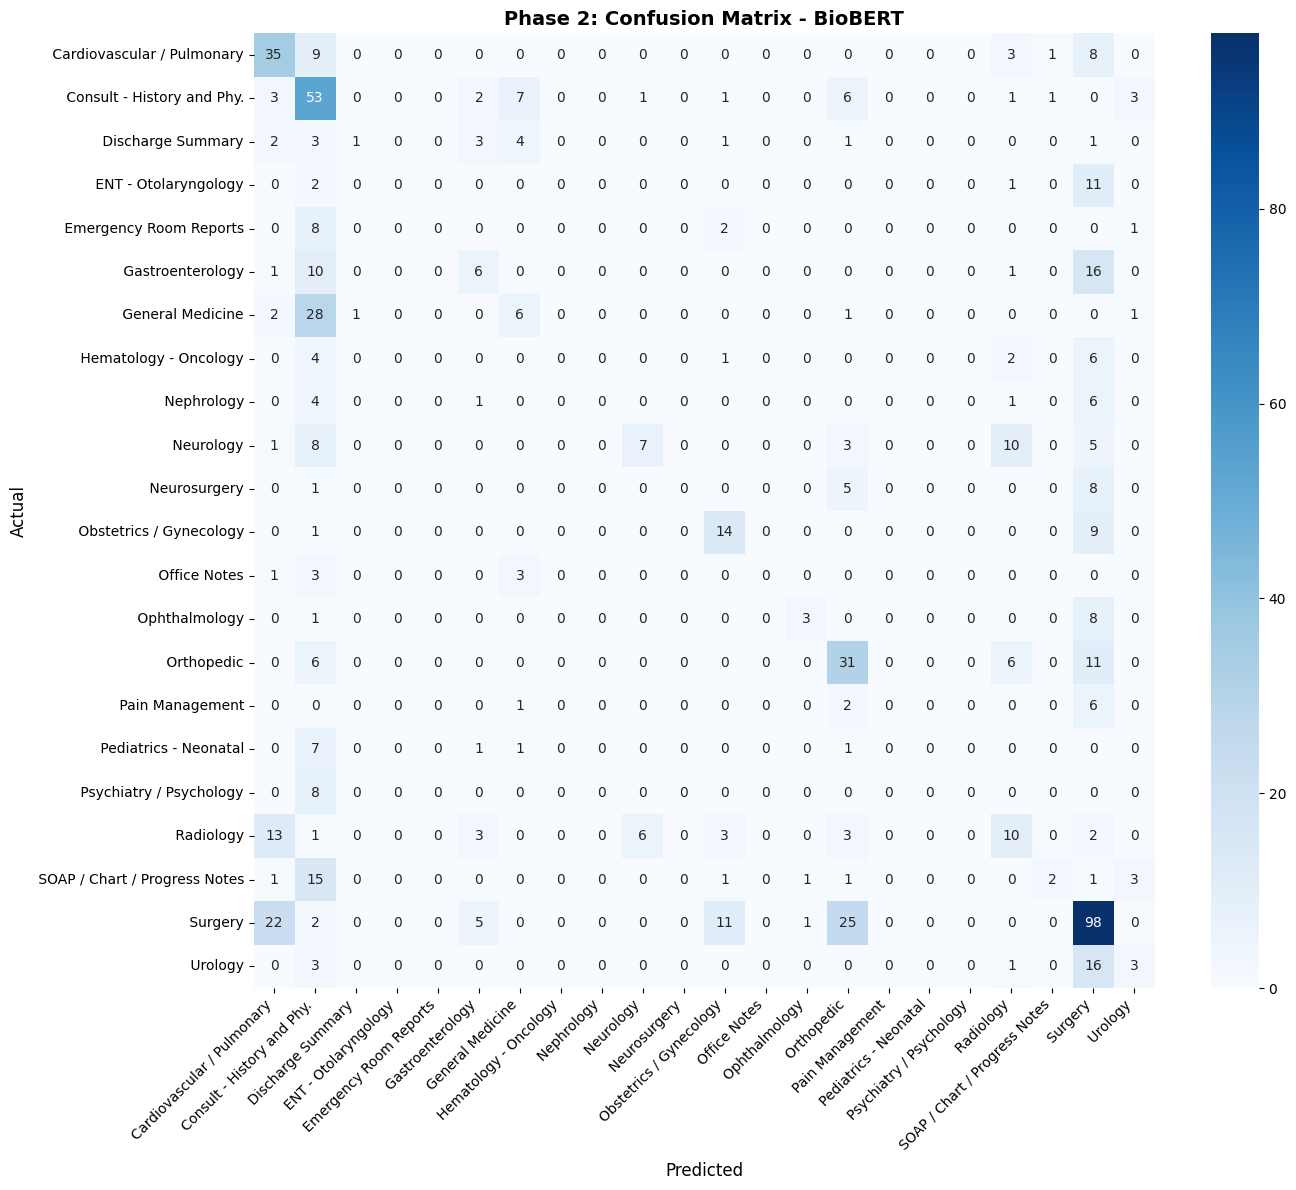

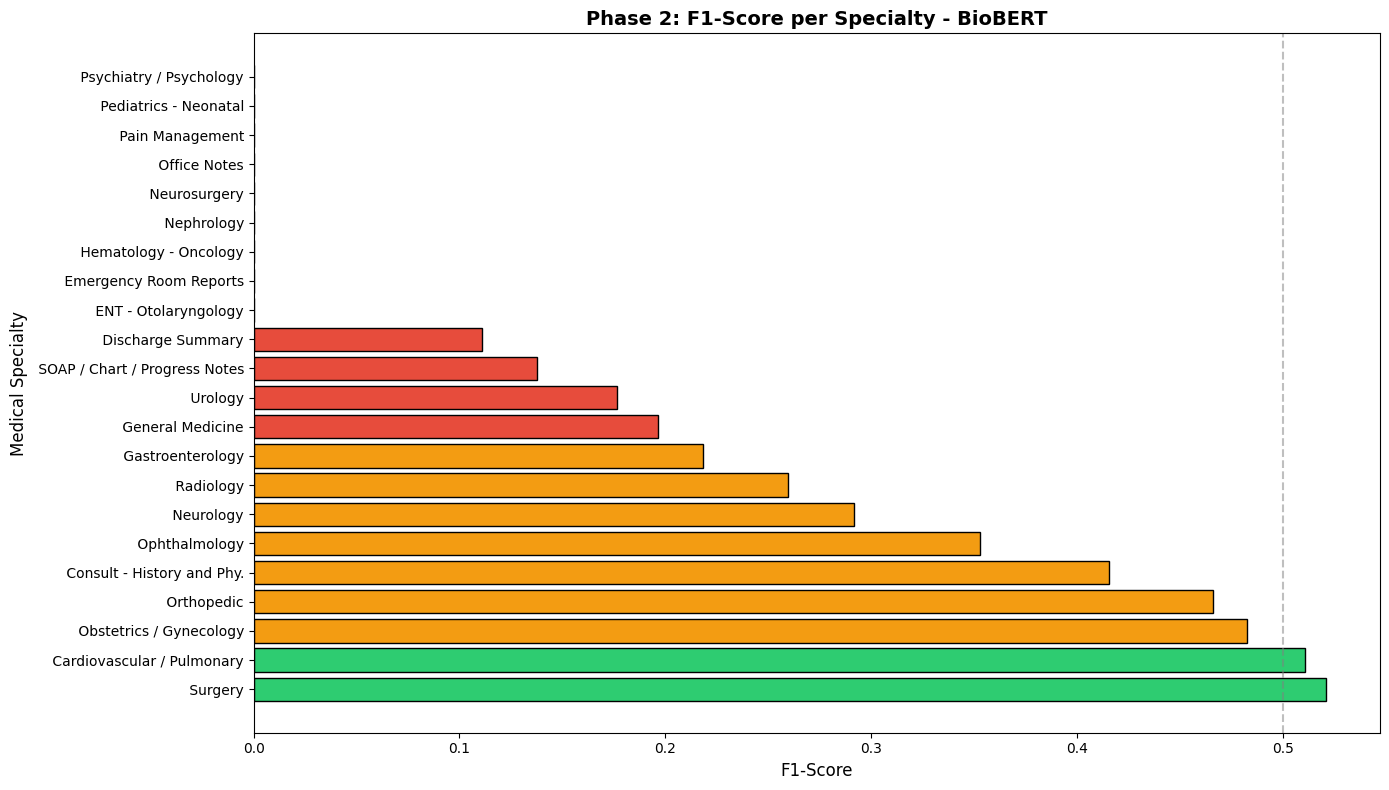

Phase 2 figures saved!


In [14]:
# === SAVE ALL FIGURES ===
# 1. Model Comparison (Phase 1 vs Phase 2)
all_results = {
    "TF-IDF+LogReg\n(Phase 1)": 0.2763,
    "BERT-base": bert_results["accuracy"],
    "BioBERT": biobert_results["accuracy"],
    "ClinicalBERT": clinicalbert_results["accuracy"],
}
names = list(all_results.keys())
accs = list(all_results.values())
colors = ["#95a5a6", "#3498db", "#e74c3c", "#2ecc71"]
plt.figure(figsize=(12, 6))
bars = plt.bar(names, accs, color=colors, edgecolor="black", width=0.6)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             "{:.2f}%".format(acc * 100), ha="center", va="bottom", fontweight="bold", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.title("Phase 1 vs Phase 2: Model Comparison", fontsize=15, fontweight="bold")
plt.ylim(0, max(accs) + 0.15)
plt.axhline(y=0.2763, color="gray", linestyle="--", alpha=0.7, label="Phase 1 Baseline")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("phase2_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Confusion Matrix - Best BERT
bert_models = {"BERT-base": bert_results, "BioBERT": biobert_results, "ClinicalBERT": clinicalbert_results}
best_bert_name = max(bert_models, key=lambda x: bert_models[x]["accuracy"])
best_bert = bert_models[best_bert_name]
cm = confusion_matrix(test_dataset["label"], best_bert["predictions"])
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Phase 2: Confusion Matrix - " + best_bert_name, fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("phase2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Per-class F1 scores
report = classification_report(test_dataset["label"], best_bert["predictions"], target_names=le.classes_, output_dict=True, zero_division=0)
class_f1 = {cls: report[cls]["f1-score"] for cls in le.classes_}
sorted_f1 = dict(sorted(class_f1.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(14, 8))
colors_list = ["#2ecc71" if v > 0.5 else "#e74c3c" if v < 0.2 else "#f39c12" for v in sorted_f1.values()]
plt.barh(list(sorted_f1.keys()), list(sorted_f1.values()), color=colors_list, edgecolor="black")
plt.xlabel("F1-Score", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)
plt.title("Phase 2: F1-Score per Specialty - " + best_bert_name, fontsize=14, fontweight="bold")
plt.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("phase2_f1_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

print("Phase 2 figures saved!")